# 01. EDA и контроли артефактов

Воспроизводит фигуры 1–5 (§7) из кэша EDA (`tools/eda_figures.py`; при отсутствии кэша пересчитывает по `data/train`) и таблицу контрольных экспериментов §5. В анализе допустимы двунаправленные фильтры и метки — это не классификатор.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'assets' else Path.cwd()
sys.path.insert(0, str(ROOT / 'tools')); sys.path.insert(0, str(ROOT / 'solution'))
import numpy as np, pandas as pd
from IPython.display import Image, Markdown, display
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)
EXP = ROOT / 'results' / 'experiments'; FIG = ROOT / 'results' / 'figures'

In [2]:
import eda_figures as ED, make_figures as MF
E = ED.compute()
MF.eda_figures(E)
print('сессий в EDA:', len(E['names']), '; NIRS 12.5 Гц:', len(E['nirs']))

→ /Users/egornakonecnyj/Desktop/2503-support-academy-oligomery-1d85e81/results/figures/erd_tfr_c3_c4_cz.png


→ /Users/egornakonecnyj/Desktop/2503-support-academy-oligomery-1d85e81/results/figures/erd_topomaps.png
→ /Users/egornakonecnyj/Desktop/2503-support-academy-oligomery-1d85e81/results/figures/fes_artifact_spectrum.png
→ /Users/egornakonecnyj/Desktop/2503-support-academy-oligomery-1d85e81/results/figures/heog_by_class.png


→ /Users/egornakonecnyj/Desktop/2503-support-academy-oligomery-1d85e81/results/figures/nirs_grand_average.png
сессий в EDA: 56 ; NIRS 12.5 Гц: 52


## 1. ERD/ERS на C3/Cz/C4

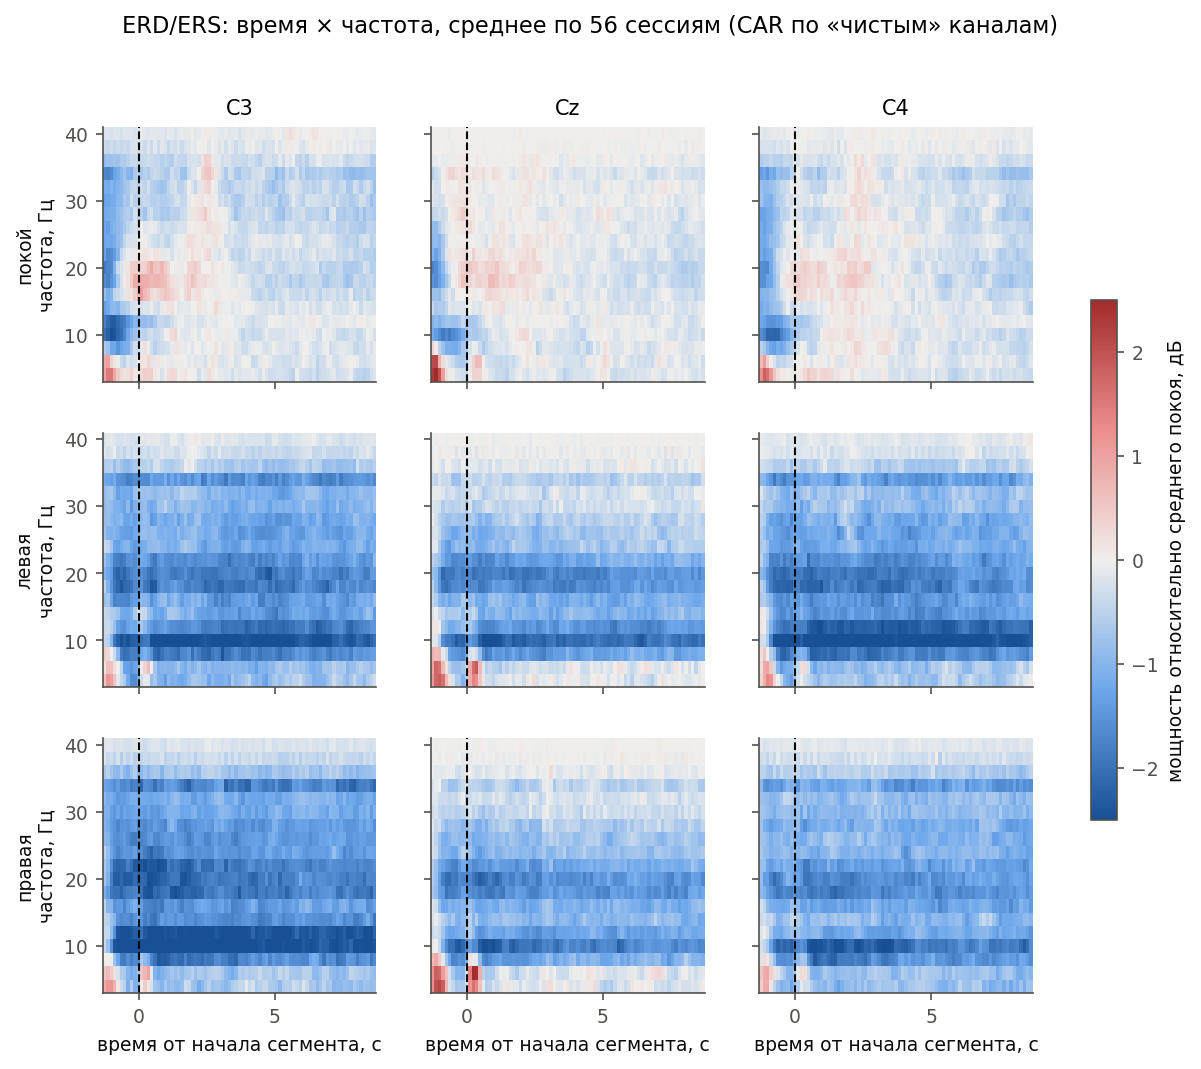

In [3]:
display(Image(filename=str(FIG / 'erd_tfr_c3_c4_cz.png')))

## 2. Топографии μ/β

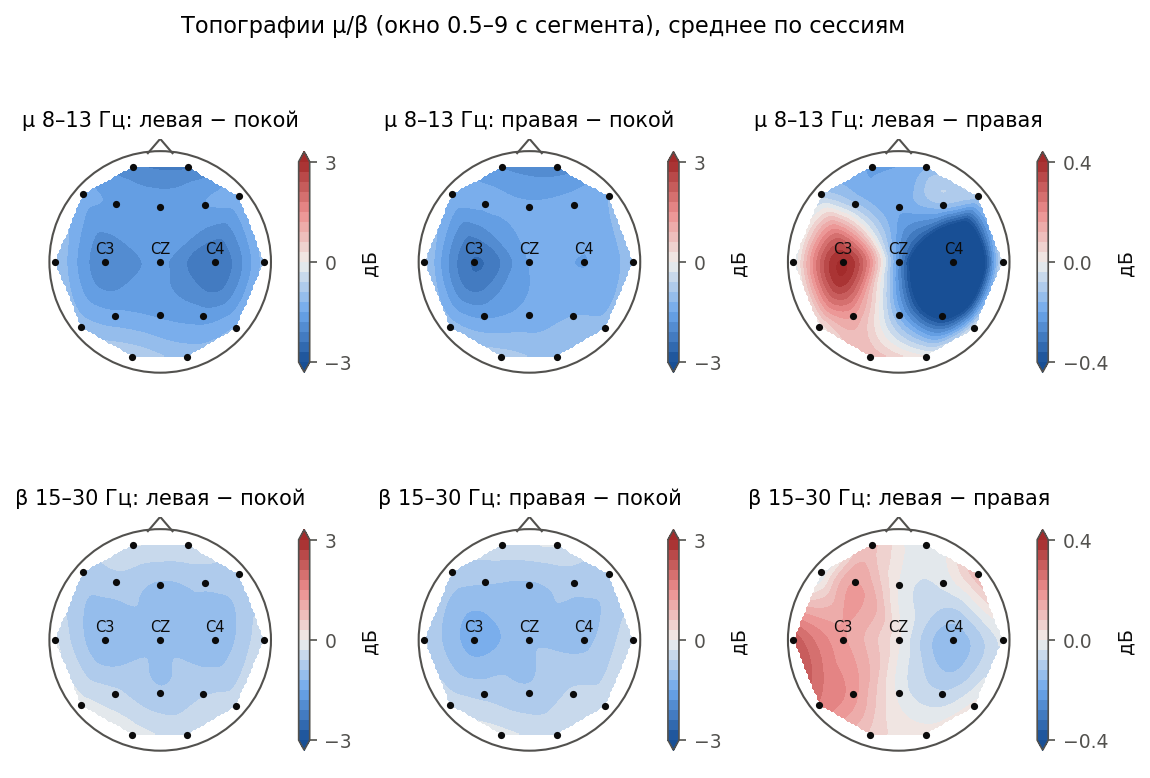

In [4]:
display(Image(filename=str(FIG / 'erd_topomaps.png')))

## 3. Артефакт ФЭС ≈ 83 Гц

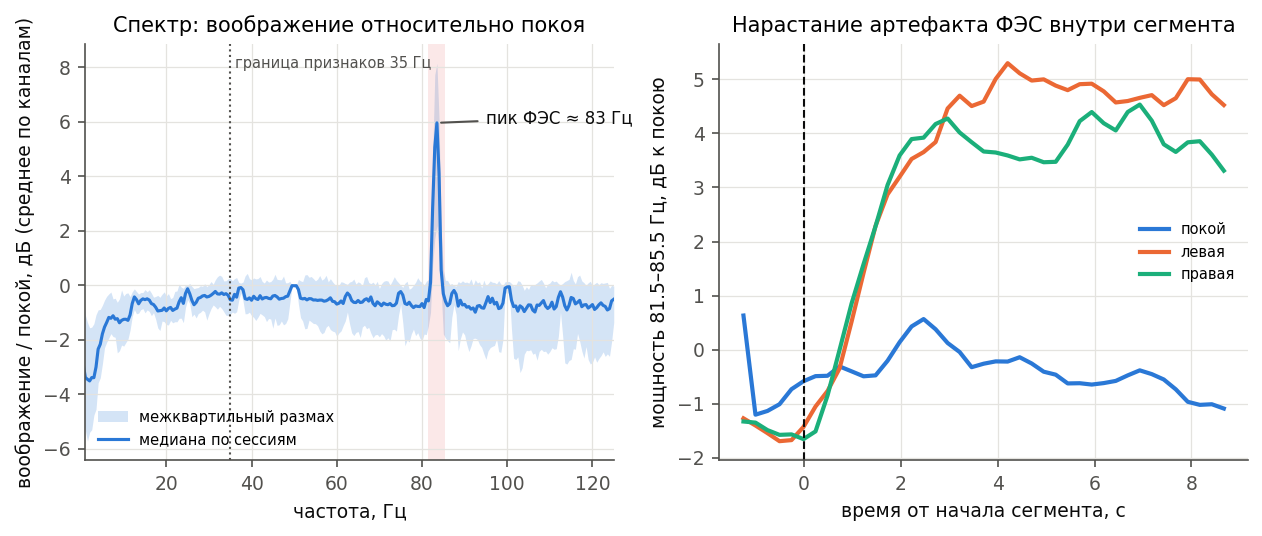

In [5]:
display(Image(filename=str(FIG / 'fes_artifact_spectrum.png')))

## 4. Горизонтальная ЭОГ

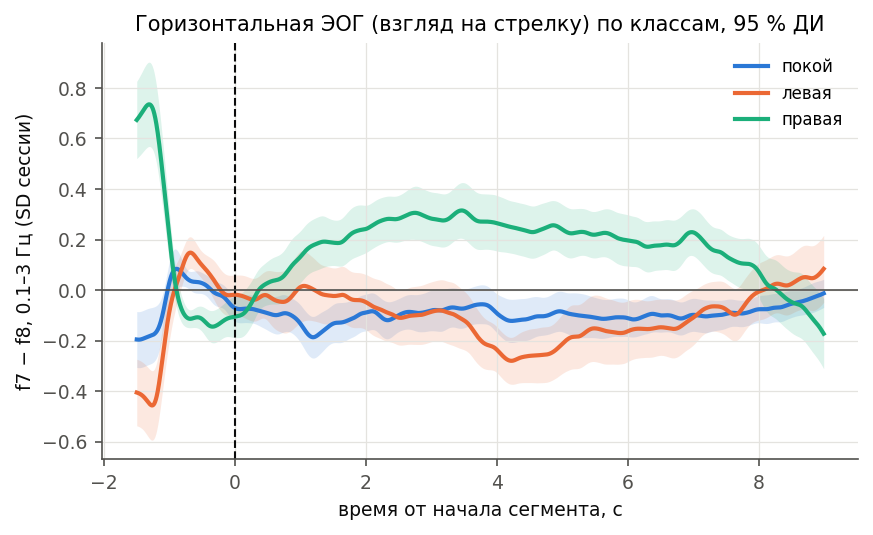

In [6]:
display(Image(filename=str(FIG / 'heog_by_class.png')))

## 5. NIRS grand average

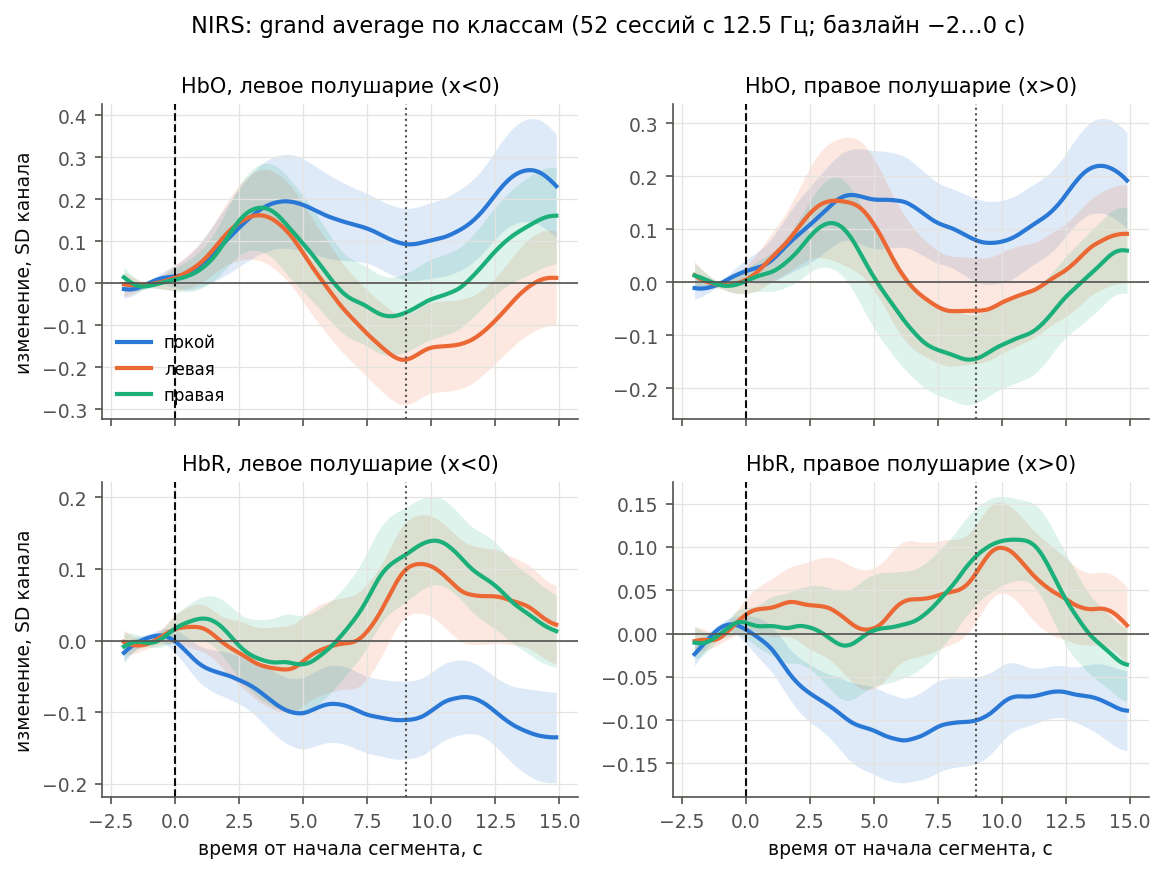

In [7]:
display(Image(filename=str(FIG / 'nirs_grand_average.png')))

## Числа EDA: сила ФЭС по пробам и ранний ERD

In [8]:
fes = pd.read_csv(ROOT / 'results/cache/fes_segments.csv')
im = fes[fes.cls > 1]
print('медиана прироста 81.5–85.5 Гц в пробах воображения, дБ:', round(im.fes_db.median(), 2))
print('доля проб < 2 дБ:', round((im.fes_db < 2).mean(), 3), ' > 6 дБ:', round((im.fes_db > 6).mean(), 3))
neuro = ROOT / 'results/cache/neuro_session.csv'
if neuro.exists():
    N = pd.read_csv(neuro)
    print('μ-латерализация, медианный AUC(Л vs П) по log C3 − log C4:', round(N.mu_lat_auc.median(), 3))
    print('ранний (0.5–2.5 с) μ-ERD относительно покоя, дБ:', round(N.early_erd_db.mean(), 2))

медиана прироста 81.5–85.5 Гц в пробах воображения, дБ: 1.72
доля проб < 2 дБ: 0.515  > 6 дБ: 0.344
μ-латерализация, медианный AUC(Л vs П) по log C3 − log C4: 0.676
ранний (0.5–2.5 с) μ-ERD относительно покоя, дБ: -2.75


## Таблица контролей §5

In [9]:
rows = []
for name in ['final', 'final_ch_sm9', 'final_ch_all17', 'final_band40', 'final_band100_LEAKDEMO', 'B3', 'B3_ch_all17', 'B3_band100_LEAKDEMO']:
    m = json.load(open(EXP / 'E11_controls' / name / 'metrics_extra.json'))['mean_over_sessions']
    rows.append({'вариант': name, 'F': m['hyb_min_f1'], 'P': m['hyb_recall'], 'EEG F': m['eeg_min_f1'],
                 'AUC покой/вообр.': m['eeg_auc_rest_im'], 'AUC Л/П': m['eeg_auc_lr'],
                 'F 1.0–2.5 с': m['hyb_minf1_t1.0'], 'AUC п/в 1.0–2.5 с': m['eeg_auc_rest_im_t1.0']})
for name in ['conf_heog', 'conf_fes', 'conf_frontocc']:
    m = json.load(open(EXP / 'E02_conf' / name / 'metrics_extra.json'))['mean_over_sessions']
    rows.append({'вариант': name, 'F': m['hyb_min_f1'], 'P': m['hyb_recall'], 'EEG F': m['eeg_min_f1'],
                 'AUC покой/вообр.': m['eeg_auc_rest_im'], 'AUC Л/П': m['eeg_auc_lr']})
pd.DataFrame(rows).round(3)

,вариант,F,P,EEG F,AUC покой/вообр.,AUC Л/П,F 1.0–2.5 с,AUC п/в 1.0–2.5 с
0,final,0.507,0.640,0.473,0.877,0.674,0.490,0.894
1,final_ch_sm9,0.500,0.635,0.471,0.874,0.667,0.492,0.898
2,final_ch_all17,0.533,0.658,0.498,0.887,0.698,0.497,0.897
3,final_band40,0.500,0.640,0.467,0.876,0.669,0.486,0.888
4,final_band100_LEAKDEMO,0.492,0.636,0.455,0.887,0.657,0.472,0.878
5,B3,0.453,0.585,0.430,0.797,0.627,0.428,0.809
6,B3_ch_all17,0.462,0.595,0.447,0.823,0.649,0.450,0.828
7,B3_band100_LEAKDEMO,0.426,0.556,0.412,0.786,0.591,0.404,0.770
8,conf_heog,0.295,0.408,0.295,0.541,0.635,NaN,NaN
9,conf_fes,0.317,0.456,0.317,0.700,0.562,NaN,NaN


In [10]:
for f in ['permutations.json', 'fes_strat_final.json', 'corr_final.json', 'neuro_final.json', 'haufe.json']:
    p = EXP / 'E11_controls' / f
    if p.exists():
        d = json.load(open(p))
        display(Markdown(f'**{f}**'))
        print(json.dumps(d if f != 'haufe.json' else {k: v for k, v in d.items() if k.startswith('L-R')}, ensure_ascii=False, indent=1)[:2500])

**permutations.json**

{
 "sessions": [
  "2025.12.01.16.04.01_N01",
  "2025.12.08.14.19.05_N02",
  "2025.12.11.12.13.46_N03",
  "2026.01.14.13.55.34_N06",
  "2026.01.20.13.28.05_N08",
  "2026.01.21.13.29.25_N09",
  "2026.01.21.15.25.36_N10",
  "2026.01.28.13.14.05_N11",
  "2026.02.12.14.14.43_N13",
  "2026.02.20.17.10.45_N14",
  "2026.02.24.16.07.40_N15",
  "2026.03.10.17.02.53_N16",
  "2026.03.23.14.24.35_N17",
  "2026.03.24.18.00.22_N18"
 ],
 "n_perm": 50,
 "lr_y_minf1": {
  "real": 0.48661151791886414,
  "null_mean": 0.37396268961853496,
  "null_95": 0.39731793598045245,
  "null_max": 0.4060114144741115,
  "p_value": 0.0196078431372549
 },
 "lr_y_recall": {
  "real": 0.6182576426987002,
  "null_mean": 0.5498669304386564,
  "null_95": 0.5649405113372696,
  "null_max": 0.5693204005154804,
  "p_value": 0.0196078431372549
 },
 "lr_y_eeg_minf1": {
  "real": 0.459354810430912,
  "null_mean": 0.35117014658671936,
  "null_95": 0.37449282732645817,
  "null_max": 0.38169033781323475,
  "p_value": 0.019607843137254

**fes_strat_final.json**

{
 "by_group": [
  {
   "group": "сильный >6 дБ",
   "recall": 0.6135,
   "recall_eeg": 0.5873,
   "recall_early": 0.6148,
   "imag_detect": 0.8827,
   "n": 537
  },
  {
   "group": "слабый <2 дБ",
   "recall": 0.4564,
   "recall_eeg": 0.4301,
   "recall_early": 0.4543,
   "imag_detect": 0.7737,
   "n": 589
  },
  {
   "group": "средний",
   "recall": 0.5543,
   "recall_eeg": 0.5259,
   "recall_early": 0.5222,
   "imag_detect": 0.8289,
   "n": 218
  }
 ],
 "n_sessions_paired": 41,
 "paired_mean": {
  "сильный >6 дБ": 0.5816,
  "слабый <2 дБ": 0.4716
 },
 "wilcoxon_p": 0.00013969240626465762
}


**corr_final.json**

{
 "conf_heog:hyb_min_f1~hyb_min_f1": {
  "spearman_r": 0.16975683113946652,
  "p": 0.2110098282553942
 },
 "conf_heog:eeg_auc_lr~hyb_auc_lr": {
  "spearman_r": 0.31169896460325197,
  "p": 0.0193602152822397
 },
 "conf_heog:eeg_auc_rest_im~hyb_auc_rest_im": {
  "spearman_r": -0.1672960918920251,
  "p": 0.21779961789226315
 },
 "conf_heog:regression_minf1": {
  "slope": 0.28972774589218925,
  "intercept": 0.4210949973677659,
  "r2": 0.016542132876554164,
  "p": 0.3448125318968075
 },
 "conf_fes:hyb_min_f1~hyb_min_f1": {
  "spearman_r": 0.2735475051264525,
  "p": 0.04135416640672793
 },
 "conf_fes:eeg_auc_lr~hyb_auc_lr": {
  "spearman_r": 0.3543866846459561,
  "p": 0.007367655665108294
 },
 "conf_fes:eeg_auc_rest_im~hyb_auc_rest_im": {
  "spearman_r": 0.4419685577580315,
  "p": 0.0006490812002253594
 },
 "conf_fes:regression_minf1": {
  "slope": 0.5267459459089443,
  "intercept": 0.33958975313915196,
  "r2": 0.08440727392502359,
  "p": 0.029842289090744406
 },
 "fes_strength~hyb_min_f1":

**neuro_final.json**

{
 "mu_lat_auc_median": 0.6760204081632653,
 "early_erd_db_mean": -2.74603993764045,
 "mu_lat_auc~eeg_auc_lr": {
  "spearman_r": 0.6431931933033701,
  "p": 9.000936983755582e-08
 },
 "mu_lat_auc~hyb_min_f1": {
  "spearman_r": 0.6582877522078163,
  "p": 3.510284003641571e-08
 },
 "early_erd_db~eeg_auc_rest_im": {
  "spearman_r": -0.7190704032809295,
  "p": 4.3156743391729e-10
 },
 "early_erd_db~hyb_min_f1": {
  "spearman_r": -0.681613123718387,
  "p": 7.346072275436124e-09
 }
}


**haufe.json**

{
 "L-R:μ 8–12 Гц": {
  "c3": 0.163,
  "cz": -0.137,
  "c4": -0.367,
  "f3": -0.008,
  "fz": -0.058,
  "f4": -0.094,
  "p3": 0.056,
  "pz": -0.079,
  "p4": -0.163,
  "c7": -0.044,
  "c8": -0.025
 },
 "L-R:β 16–24 Гц": {
  "c3": 0.099,
  "cz": 0.001,
  "c4": -0.056,
  "f3": 0.064,
  "fz": -0.003,
  "f4": -0.02,
  "p3": 0.102,
  "pz": -0.008,
  "p4": -0.034,
  "c7": 0.172,
  "c8": -0.063
 }
}


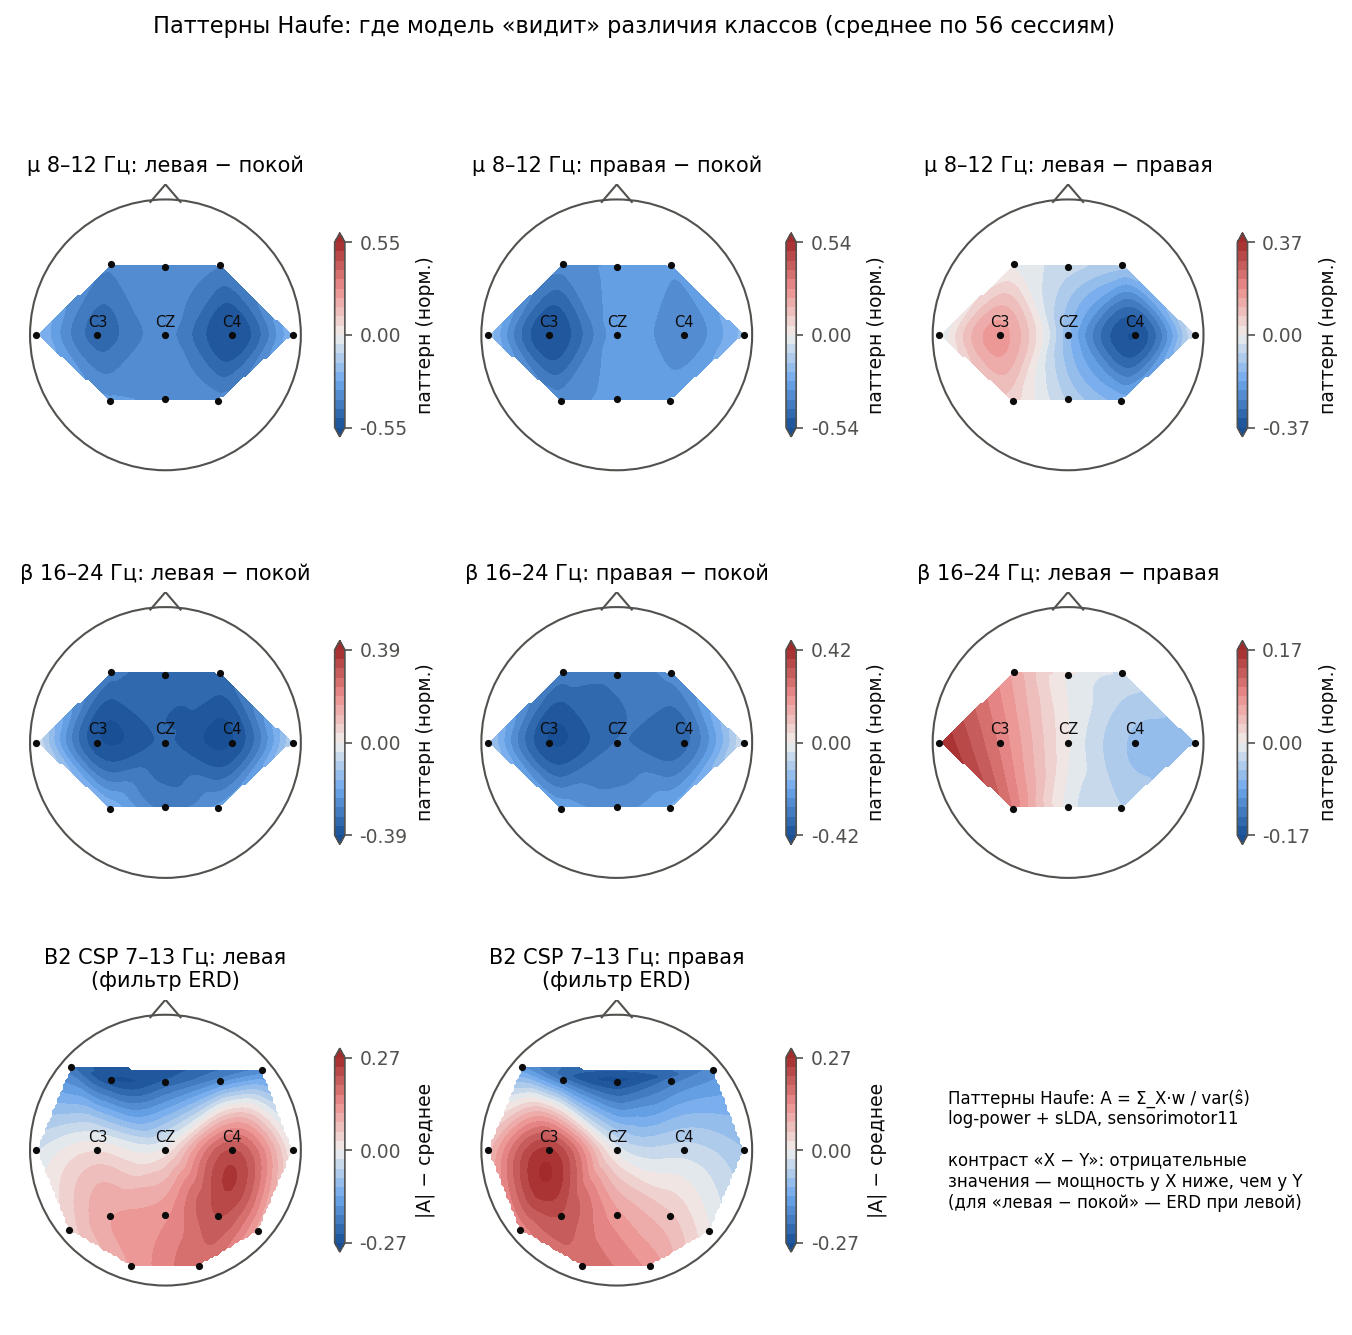

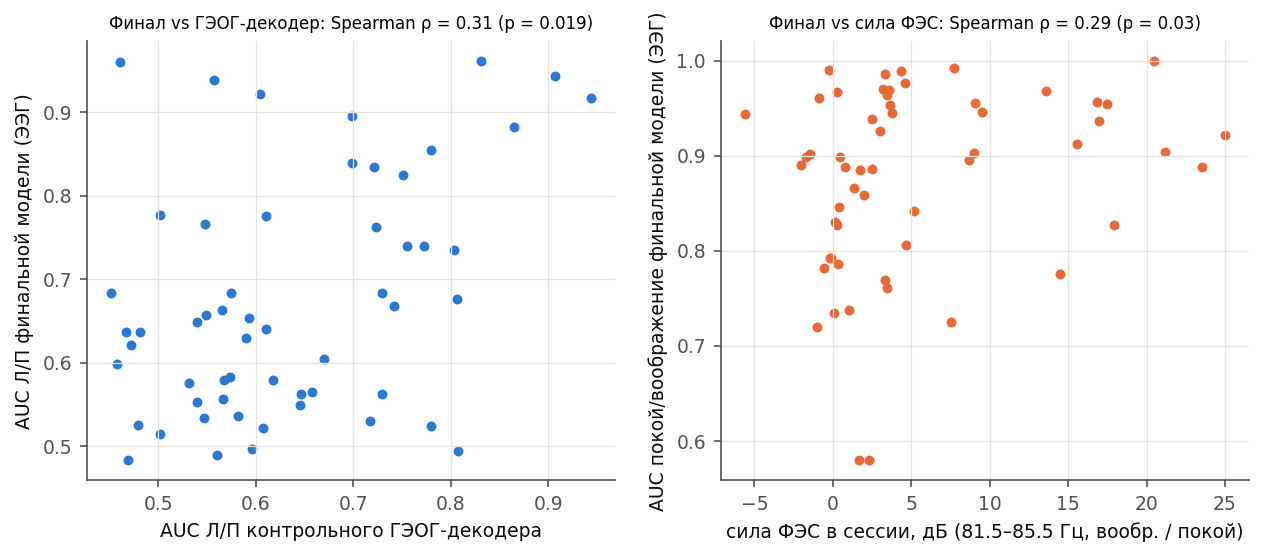

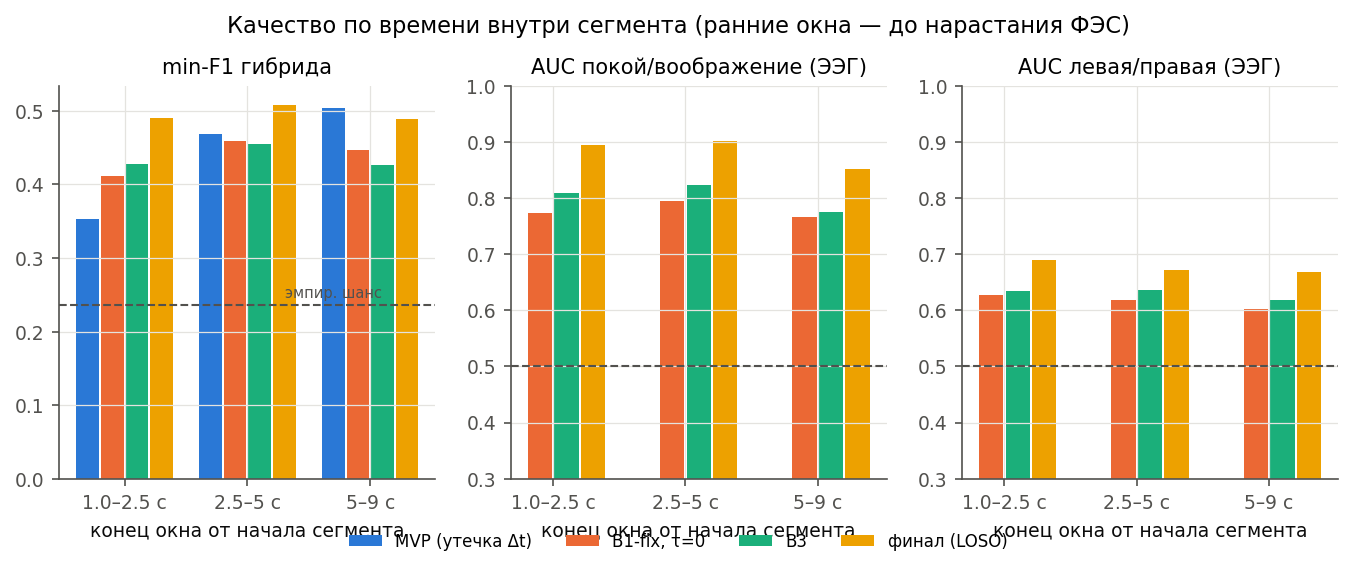

In [11]:
for f in ['haufe_patterns.png', 'controls_scatter.png', 'time_in_segment.png']:
    if (FIG / f).exists(): display(Image(filename=str(FIG / f)))